<a href="https://colab.research.google.com/github/dudavsr/heap/blob/main/Teste_EB_2_HEAP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import heapq
import random
from collections import defaultdict

class Jogador:
    def __init__(self, id, elo, tempo_espera):
        self.id = id
        self.elo = elo
        self.tempo_espera = tempo_espera

    def __repr__(self):
        return (f"Jogador({self.id}, "
                f"Elo = {self.elo}, "
                f"Espera = {self.tempo_espera})")

class Matchmaking:
    def __init__(self, diferenca_max_elo=300):
        self.heap_espera = []
        self.heaps_por_elo = defaultdict(list)
        self.jogadores_ativos = {}
        self.diferenca_max_elo = diferenca_max_elo

    def adicionar_jogador(self, jogador):
        prioridade_espera = -jogador.tempo_espera
        self.jogadores_ativos[jogador.id] = jogador
        heapq.heappush(self.heap_espera, (prioridade_espera, jogador.id, jogador))
        heapq.heappush(self.heaps_por_elo[jogador.elo], (prioridade_espera, jogador.id, jogador))

    def limpar_heap_espera(self):
        while self.heap_espera:
            prioridade, id_jogador, jogador = self.heap_espera[0]
            if id_jogador in self.jogadores_ativos:
                break
            heapq.heappop(self.heap_espera)

    def buscar_melhor_por_elo(self, elo, id_excluido):
        heap = self.heaps_por_elo[elo]
        removidos_temp = []

        while heap:
            prioridade, id_jogador, jogador = heapq.heappop(heap)
            if id_jogador not in self.jogadores_ativos:
                continue
            if id_jogador == id_excluido:
                removidos_temp.append((prioridade, id_jogador, jogador))
                continue

            candidato = (prioridade, id_jogador, jogador)
            heapq.heappush(heap, candidato)
            for item in removidos_temp:
                heapq.heappush(heap, item)
            return candidato

        for item in removidos_temp:
            heapq.heappush(heap, item)
        return None

    def criar_partida(self):
        self.limpar_heap_espera()

        if len(self.jogadores_ativos) < 2:
            return None

        prioridade1, id1, jogador1 = heapq.heappop(self.heap_espera)

        melhor_candidato = None
        menor_diferenca = None

        for diferenca in range(self.diferenca_max_elo + 1):
            elos_p_verificar = []
            elo_menor = jogador1.elo - diferenca
            elo_maior = jogador1.elo + diferenca
            elos_p_verificar.append(elo_menor)
            if elo_maior != elo_menor:
                elos_p_verificar.append(elo_maior)

            candidatos = []
            for elo in elos_p_verificar:
                candidato = self.buscar_melhor_por_elo(elo, id_excluido=jogador1.id)
                if candidato is not None:
                    candidatos.append(candidato)

            if candidatos:
                melhor_candidato = min(candidatos, key=lambda item: (item[0], item[1]))
                menor_diferenca = diferenca
                break

        if melhor_candidato is None:
            heapq.heappush(self.heap_espera, (prioridade1, id1, jogador1))
            return None

        jogador2 = melhor_candidato[2]
        del self.jogadores_ativos[jogador1.id]
        del self.jogadores_ativos[jogador2.id]
        return jogador1, jogador2, menor_diferenca

    def tamanho(self):
        return len(self.jogadores_ativos)

def heapsort_jogadores(jogadores):
    heap = []
    for jogador in jogadores:
        heapq.heappush(heap, (jogador.elo, jogador.id, jogador))

    ordenado = []
    while heap:
        ordenado.append(heapq.heappop(heap)[2])
    return ordenado

fila = Matchmaking(diferenca_max_elo=300)

todos_jogadores = []
for i in range(20):
    elo = random.randint(500, 2500)
    espera = random.randint(1, 30)
    jogador = Jogador(i, elo, espera)
    todos_jogadores.append(jogador)
    fila.adicionar_jogador(jogador)


print("Jogadores Inseridos:\n")
for jogador in todos_jogadores:
    print(jogador)
print("\nPartidas Criadas:\n")
while fila.tamanho() >= 2:
    partida = fila.criar_partida()
    if partida is None:
        print("Não há mais pares compatíveis!\n")
        break
    jogador1, jogador2, diferenca = partida
    print(jogador1, " VS ", jogador2, f"| Diferença de elo: {diferenca}")
print("\nJogadores Ordenados por elo:\n")
jogadores_ordenados = heapsort_jogadores(todos_jogadores)
for jogador in jogadores_ordenados:
    print(jogador)

Jogadores Inseridos:

Jogador(0, Elo = 856, Espera = 10)
Jogador(1, Elo = 2392, Espera = 17)
Jogador(2, Elo = 1495, Espera = 6)
Jogador(3, Elo = 1510, Espera = 14)
Jogador(4, Elo = 1039, Espera = 24)
Jogador(5, Elo = 2280, Espera = 26)
Jogador(6, Elo = 1383, Espera = 20)
Jogador(7, Elo = 2303, Espera = 3)
Jogador(8, Elo = 824, Espera = 28)
Jogador(9, Elo = 2111, Espera = 2)
Jogador(10, Elo = 2236, Espera = 9)
Jogador(11, Elo = 1167, Espera = 2)
Jogador(12, Elo = 929, Espera = 10)
Jogador(13, Elo = 1377, Espera = 4)
Jogador(14, Elo = 1335, Espera = 16)
Jogador(15, Elo = 2051, Espera = 27)
Jogador(16, Elo = 2100, Espera = 11)
Jogador(17, Elo = 2386, Espera = 28)
Jogador(18, Elo = 717, Espera = 2)
Jogador(19, Elo = 1091, Espera = 16)

Partidas Criadas:

Jogador(8, Elo = 824, Espera = 28)  VS  Jogador(0, Elo = 856, Espera = 10) | Diferença de elo: 32
Jogador(17, Elo = 2386, Espera = 28)  VS  Jogador(1, Elo = 2392, Espera = 17) | Diferença de elo: 6
Jogador(15, Elo = 2051, Espera = 27)  VS 

Jogadores testados: 100    Tempo médio: 0.004765 segundos    Partidas médias: 48
Jogadores testados: 500    Tempo médio: 0.004701 segundos    Partidas médias: 247
Jogadores testados: 1000    Tempo médio: 0.008076 segundos    Partidas médias: 498
Jogadores testados: 2000    Tempo médio: 0.015019 segundos    Partidas médias: 998
Jogadores testados: 5000    Tempo médio: 0.037055 segundos    Partidas médias: 2497
Jogadores testados: 10000    Tempo médio: 0.079669 segundos    Partidas médias: 4997
Jogadores testados: 20000    Tempo médio: 0.204738 segundos    Partidas médias: 9997


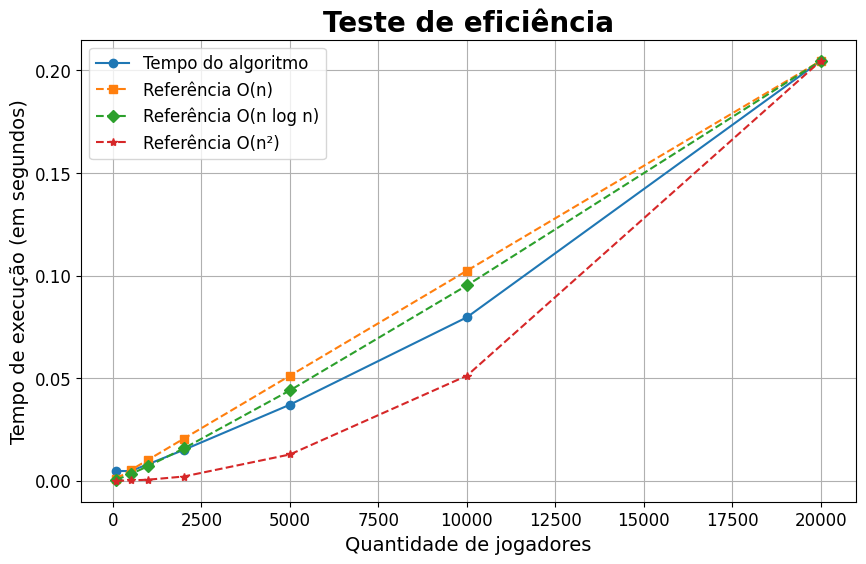

In [ ]:
import time
import math
import random
import matplotlib.pyplot as plt

def testar_matchmaking(n_jogadores, diferenca_max_elo=300):
    fila_teste = Matchmaking(diferenca_max_elo=diferenca_max_elo)
    jogadores = []
    inicio = time.perf_counter()

    for i in range(n_jogadores):
        elo = random.randint(500, 2500)
        espera = random.randint(1, 30)
        jogador = Jogador(i, elo, espera)
        jogadores.append(jogador)
        fila_teste.adicionar_jogador(jogador)

    partidas_criadas = 0

    while fila_teste.tamanho() >= 2:
        partida = fila_teste.criar_partida()

        if partida is None:
            break

        partidas_criadas += 1

    fim = time.perf_counter()
    tempo_total = fim - inicio
    return tempo_total, partidas_criadas

tamanhos = [100, 500, 1000, 2000, 5000, 10000, 20000]
tempos = []
partidas = []
repeticoes = 32

for n in tamanhos:
    tempos_repeticoes = []
    partidas_repeticoes = []

    for _ in range(repeticoes):
        tempo, qtd_partidas = testar_matchmaking(n)
        tempos_repeticoes.append(tempo)
        partidas_repeticoes.append(qtd_partidas)

    tempo_medio = sum(tempos_repeticoes) / repeticoes
    partidas_media = sum(partidas_repeticoes) / repeticoes
    tempos.append(tempo_medio)
    partidas.append(partidas_media)

    print(f"Jogadores testados: {n}    "
        f"Tempo médio: {tempo_medio:.6f} segundos    "
        f"Partidas médias: {partidas_media:.0f}")

n_log_n = [n * math.log2(n) for n in tamanhos]
n_linear = [n for n in tamanhos]
n_quadratico = [n ** 2 for n in tamanhos]

def normalizar(curva, referencia):
    fator = referencia[-1] / curva[-1]
    return [valor * fator for valor in curva]

n_log_n_normalizado = normalizar(n_log_n, tempos)
n_linear_normalizado = normalizar(n_linear, tempos)
n_quadratico_normalizado = normalizar(n_quadratico, tempos)

plt.figure(figsize=(10, 6))
plt.plot(tamanhos, tempos, marker="o", label="Tempo do algoritmo")
plt.plot(tamanhos, n_linear_normalizado, linestyle="--", marker="s", label="Referência O(n)")
plt.plot(tamanhos, n_log_n_normalizado, linestyle="--", marker="D", label="Referência O(n log n)")
plt.plot(tamanhos, n_quadratico_normalizado, linestyle="--", marker="*", label="Referência O(n²)")
plt.xlabel("Quantidade de jogadores", fontsize=14)
plt.ylabel("Tempo de execução (em segundos)", fontsize=14)
plt.title("Teste de eficiência", fontsize=20, fontweight="bold")
plt.legend(fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True)
plt.show()

Jogadores testados: 50000   Tempo médio: 0.634681 segundos    Partidas médias: 24998
Jogadores testados: 100000   Tempo médio: 1.393384 segundos    Partidas médias: 49998
Jogadores testados: 200000   Tempo médio: 3.008336 segundos    Partidas médias: 99997
Jogadores testados: 350000   Tempo médio: 5.704827 segundos    Partidas médias: 174997
Jogadores testados: 500000   Tempo médio: 8.511244 segundos    Partidas médias: 249997


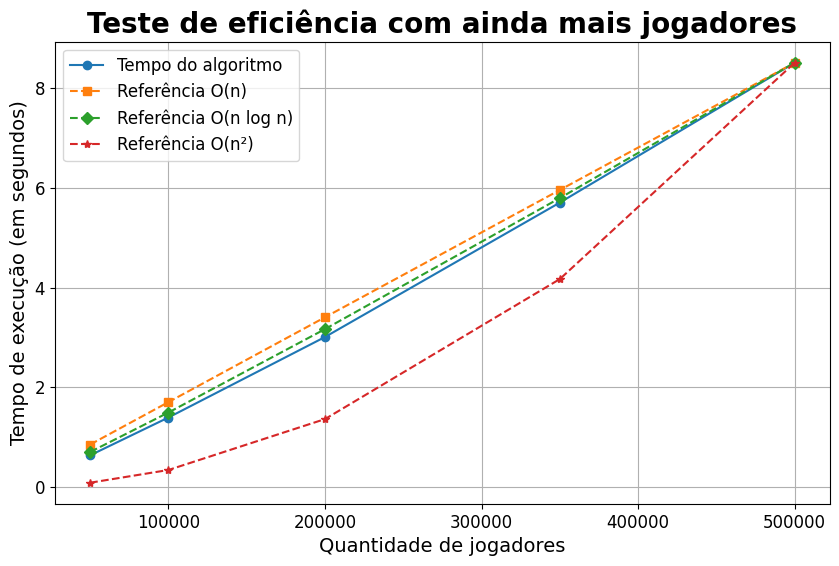

In [ ]:
import time
import math
import random
import matplotlib.pyplot as plt

def testar_matchmaking(n_jogadores, diferenca_max_elo=300):
    fila_teste = Matchmaking(diferenca_max_elo=diferenca_max_elo)
    jogadores = []
    inicio = time.perf_counter()

    for i in range(n_jogadores):
        elo = random.randint(500, 2500)
        espera = random.randint(1, 30)
        jogador = Jogador(i, elo, espera)
        jogadores.append(jogador)
        fila_teste.adicionar_jogador(jogador)

    partidas_criadas = 0

    while fila_teste.tamanho() >= 2:
        partida = fila_teste.criar_partida()

        if partida is None:
            break

        partidas_criadas += 1

    fim = time.perf_counter()
    tempo_total = fim - inicio
    return tempo_total, partidas_criadas

tamanhos = [50000, 100000, 200000, 350000, 500000]
tempos = []
partidas = []
repeticoes = 32

for n in tamanhos:
    tempos_repeticoes = []
    partidas_repeticoes = []

    for _ in range(repeticoes):
        tempo, qtd_partidas = testar_matchmaking(n)
        tempos_repeticoes.append(tempo)
        partidas_repeticoes.append(qtd_partidas)

    tempo_medio = sum(tempos_repeticoes) / repeticoes
    partidas_media = sum(partidas_repeticoes) / repeticoes
    tempos.append(tempo_medio)
    partidas.append(partidas_media)

    print(f"Jogadores testados: {n}   "
        f"Tempo médio: {tempo_medio:.6f} segundos    "
        f"Partidas médias: {partidas_media:.0f}")

n_log_n = [n * math.log2(n) for n in tamanhos]
n_linear = [n for n in tamanhos]
n_quadratico = [n ** 2 for n in tamanhos]

def normalizar(curva, referencia):
    fator = referencia[-1] / curva[-1]
    return [valor * fator for valor in curva]

n_log_n_normalizado = normalizar(n_log_n, tempos)
n_linear_normalizado = normalizar(n_linear, tempos)
n_quadratico_normalizado = normalizar(n_quadratico, tempos)

plt.figure(figsize=(10, 6))
plt.plot(tamanhos, tempos, marker="o", label="Tempo do algoritmo")
plt.plot(tamanhos, n_linear_normalizado, linestyle="--", marker="s", label="Referência O(n)")
plt.plot(tamanhos, n_log_n_normalizado, linestyle="--", marker="D", label="Referência O(n log n)")
plt.plot(tamanhos, n_quadratico_normalizado, linestyle="--", marker="*", label="Referência O(n²)")
plt.xlabel("Quantidade de jogadores", fontsize=14)
plt.ylabel("Tempo de execução (em segundos)", fontsize=14)
plt.title("Teste de eficiência com ainda mais jogadores", fontsize=20, fontweight="bold")
plt.legend(fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True)
plt.show()